In [25]:
using Plots, LaTeXStrings
pgfplotsx()


Plots.PGFPlotsXBackend()

In [9]:
f(m, h, T) = -m^2 -h*m + T*((1+m)*log(1+m) + (1-m)*log(1-m)) -2*T*log(2)
g(m,h,T) = f(m,h,T) - f(0, h, T)

g (generic function with 1 method)

In [3]:
m = LinRange(-1+0.001, 1-0.001, 100)
m = collect(m)
append!(m,0)
m = sort(m)
ind = findall(x->x==0, m);

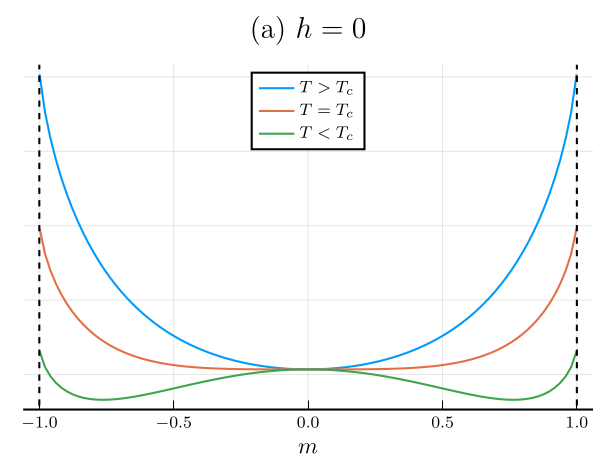

In [4]:
tgtc = f.(m,0, 1.3)
tetc = f.(m,0, 1.0)
tltc = f.(m,0, 0.76)

dist1 = -tgtc[ind] + tetc[ind]
dist2 =  tltc[ind] - tetc[ind]


plot(m, tgtc .+ dist1, label=L"T>T_c")
plot!(m, tetc, label=L"T=T_c")
plot!(m, tltc .- dist2, label=L"T<T_c", yaxis=false, legend=:top)

vline!([-1], ls=:dash, c="black", label="")
p1= vline!([1], ls=:dash, c="black", label="", size=(450,300), xlabel=L"m", title=L"(a) $h= 0$",)


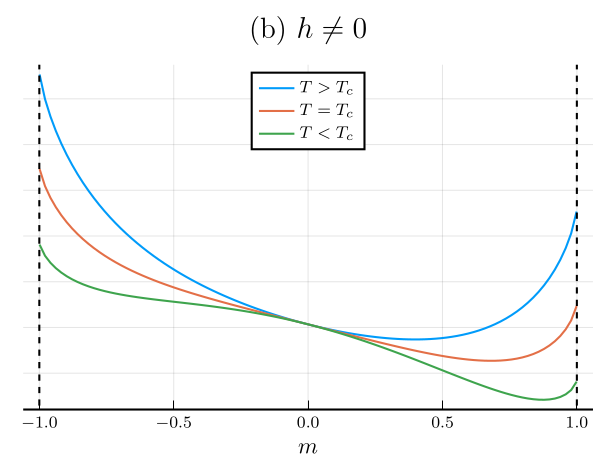

In [5]:
tgtc = f.(m,0.3, 1.3)
tetc = f.(m,0.3, 1.0)
tltc = f.(m,0.3, 0.76)

dist1 = -tgtc[ind] + tetc[ind]
dist2 =  tltc[ind] - tetc[ind]


plot(m, tgtc .+ dist1, label=L"T>T_c")
plot!(m, tetc, label=L"T=T_c")
plot!(m, tltc .- dist2, label=L"T<T_c", yaxis=false, legend=:top)

vline!([-1], ls=:dash, c="black", label="")
p2= vline!([1], ls=:dash, c="black", label="", size=(450,300), xlabel=L"m", title=L"(b) $h\neq 0$")


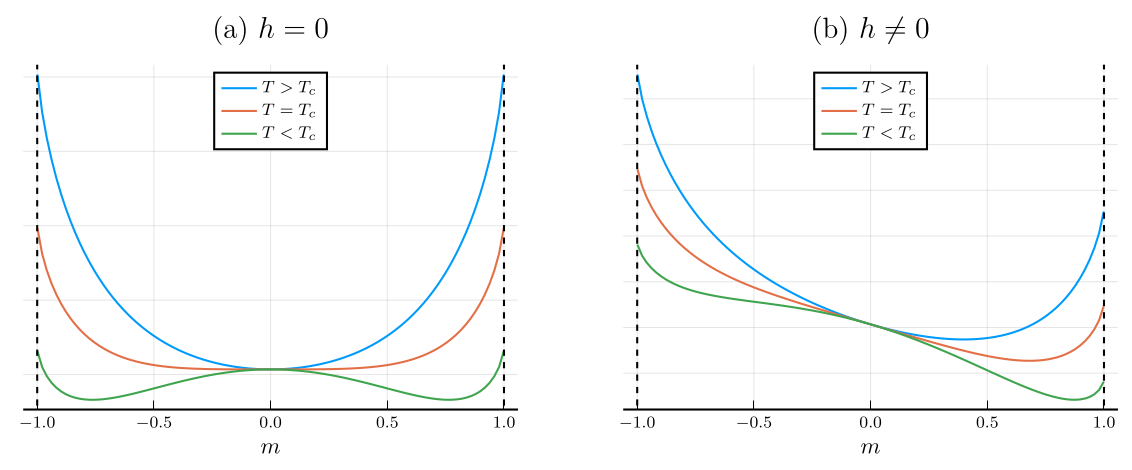

In [58]:
plot(p1,p2, size=(800,300))

In [59]:
savefig("L_vs_m_h.pdf")

"/home/shaggy1304/IISER/IISER_Courses/Notes/AdvStatMech/codes/L_vs_m_h.pdf"

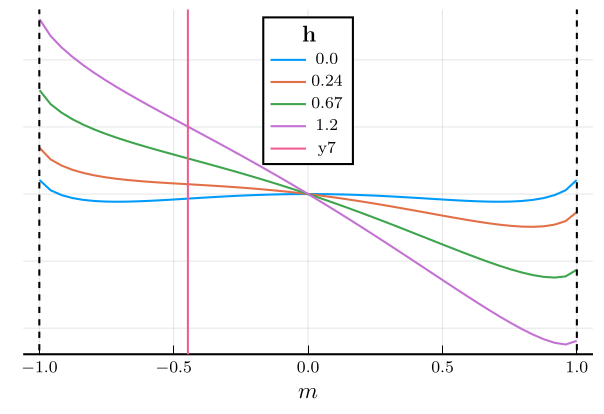

In [ ]:
L1 = f.(m,0.0, 0.8) .-f(0,0.0, 0.8)
L2 = f.(m,0.24, 0.8).-f(0,0.24, 0.8)
L3 = f.(m,0.67, 0.8).-f(0,0.67, 0.8)
L4 = f.(m,1.2, 0.8).-f(0,1.2, 0.8)




plot(m, L1 , label=L"0.0")
plot!(m, L2, label=L"0.24")
plot!(m, L3, label=L"0.67", yaxis=false, legend=:top)
plot!(m, L4, label=L"1.2", yaxis=false, legend=:top)
plot!(legendtitle="h")
vline!([-1], ls=:dash, c="black", label="")
p2= vline!([1], ls=:dash, c="black", label="", size=(450,300), xlabel=L"m")

hsp(m) = ()

In [29]:
savefig("spinodal.pdf")

"/home/shaggy1304/IISER/IISER_Courses/Notes/AdvStatMech/codes/spinodal.pdf"

In [6]:
h(θ, m) = (θ/2)* log((1+m)/(1-m)) - m 
hst(θ) = (θ/2)* log((1+sqrt(1-θ))/(1-sqrt(1-θ))) - sqrt(1-θ) 

hst (generic function with 1 method)

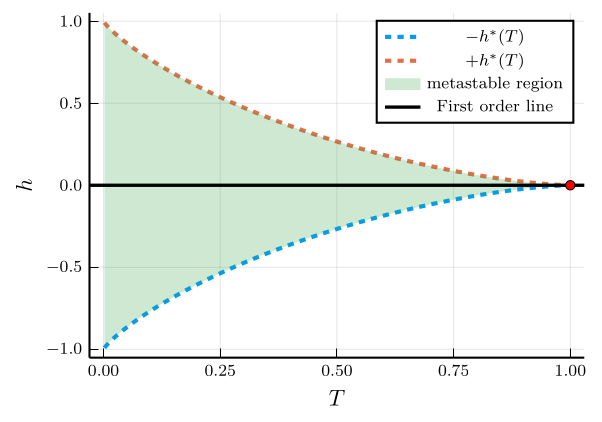

In [80]:
using Plots

# spinodal field
function h_spinodal(theta)
    m = sqrt.(1 .- theta)
    return (theta ./ 2) .* log.((1 .+ m) ./ (1 .- m)) .- m
end

T = range(0.0, 0.999, length=500)
hs = h_spinodal(θ)

plot(T,  hs,
     lw=2, label=L"-h^*(T)",
     xlabel=L"T", ylabel=L"h", ls=:dash)

plot!(T, -hs,
      lw=2, label=L"+h^*(T)", ls=:dash)

# shaded metastable region
plot!(T, hs,
      fillrange = -hs,
      fillalpha = 0.25,
      label="metastable region",linealpha = 0)
plot!(legend=:topright)
scatter!([1], [0], c="red", ms=3, msw=0.4, label="")
hline!([0], c="black", lw=1.6, label="First order line", size=(400, 300))

In [81]:
savefig("hvsT.pdf")

"/home/shaggy1304/IISER/IISER_Courses/Notes/AdvStatMech/codes/hvsT.pdf"

In [66]:
using FiniteDifferences

fd1 = central_fdm(2, 1)   # 2nd order accurate, 1st derivative
   # 2nd order accurate, 2nd derivative

   hval = 0.5
Tval = 0.84

g(x,h,T) = f(x, h, T) - f(0, h, T)
dfdm(m) = fd1(x -> g(x, hval, Tval), m)


dfdm (generic function with 1 method)

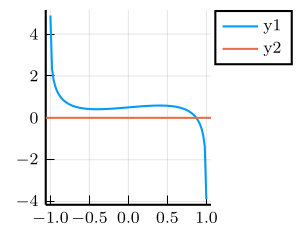

In [67]:
plot(m, -dfdm.(m), size=(200,200))
hline!([0])

In [83]:
using Roots

In [4]:
f(m,T,h) = m - tanh((1/(2*T)*h) + m/T)

g(m,T,h) = f(m,T,h) - f(0, T,h)

g (generic function with 1 method)

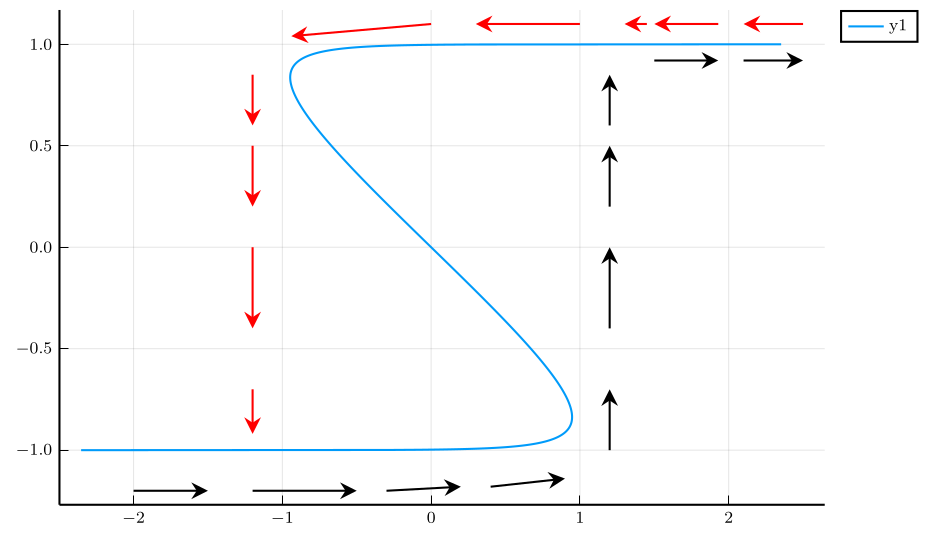

In [7]:
m = LinRange(-0.999999, 0.999999, 2000)
plot(h.(m,0.3), m)
h(m,T) = 2*T*atanh(m) - 2*m
plot(h.(m,0.3),m)
plot!([-2,-1.5], [-1.2, -1.2], arrow=(:closed, 8.0), c=:black, label="")
plot!([-1.2,-0.5], [-1.2, -1.2], arrow=(:closed, 8.0), c=:black, label="")
plot!([-0.3,0.2], [-1.2, -1.18], arrow=(:closed, 8.0), c=:black, label="")
plot!([0.4,0.9], [-1.18, -1.14], arrow=(:closed, 8.0), c=:black, label="")
plot!([1.2,1.2], [-1, -0.7], arrow=(:closed, 8.0), c=:black, label="")
plot!([1.2,1.2], [-0.4, 0.0], arrow=(:closed, 8.0), c=:black, label="")
plot!([1.2,1.2], [0.2, 0.5], arrow=(:closed, 8.0), c=:black, label="")
plot!([1.2,1.2], [0.6, 0.85], arrow=(:closed, 8.0), c=:black, label="")
plot!([1.5,1.93], [0.92, 0.92], arrow=(:closed, 8.0), c=:black, label="")
plot!([2.1,2.5], [0.92, 0.92], arrow=(:closed, 8.0), c=:black, label="")
plot!([-1.2,-1.2], [-0.7,-0.92], arrow=(:closed, 8.0), c=:red, label="")
plot!([-1.2,-1.2], [0.0,-0.4], arrow=(:closed, 8.0), c=:red, label="")
plot!([-1.2,-1.2], [0.5,0.2], arrow=(:closed, 8.0), c=:red, label="")
plot!([-1.2,-1.2], [0.85,0.6], arrow=(:closed, 8.0), c=:red, label="")
plot!([1.93,1.5], [1.1, 1.1], arrow=(:closed, 8.0), c=:red, label="")
plot!([2.5,2.1], [1.1, 1.1], arrow=(:closed, 8.0), c=:red, label="")
plot!([1.45,1.3], [1.1, 1.1], arrow=(:closed, 8.0), c=:red, label="")
plot!([1,0.3], [1.1, 1.1], arrow=(:closed, 8.0), c=:red, label="")
plot!([0,-0.94], [1.1, 1.04], arrow=(:closed, 8.0), c=:red, label="")

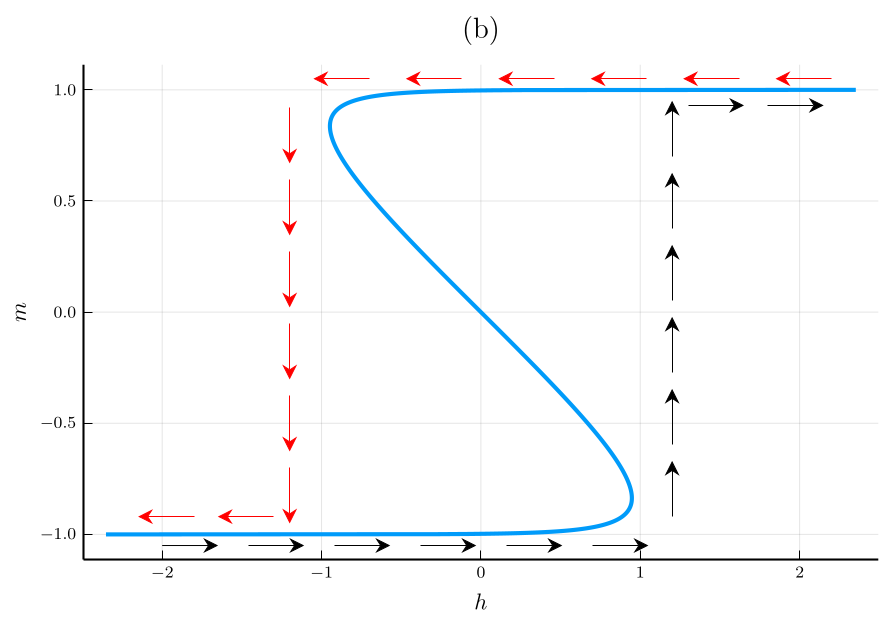

In [39]:
using Plots

h(m,T) = 2*T*atanh(m) - 2*m
T = 0.3

m = range(-0.999999, 0.999999, length=2000)
plot(h.(m,T), m,
     lw=2,
     xlabel="h",
     ylabel="m",
     legend=false)

x_bot = range(-2.0, 0.7, length=6)
y_bot = fill(-1.05, length(x_bot))

dx = fill(0.35, length(x_bot))
dy = zeros(length(x_bot))

quiver!(x_bot, y_bot,
        quiver=(dx, dy),
        arrow=(:closed,7),
        color=:black)
y_right = range(-0.92, 0.7, length=6)
x_right = fill(1.2, length(y_right))

dx = zeros(length(y_right))
dy = fill(0.25, length(y_right))

quiver!(x_right, y_right,
        quiver=(dx, dy),
        arrow=(:closed,7),
        color=:black)

x_top = range(2.2, -0.7, length=6)
y_top = fill(1.05, length(x_top))

dx = fill(-0.35, length(x_top))
dy = zeros(length(x_top))

quiver!(x_top, y_top,
        quiver=(dx, dy),
        arrow=(:closed,7),
        color=:red)
y_left = range(0.92, -0.7, length=6)
x_left = fill(-1.2, length(y_left))

dx = zeros(length(y_left))
dy = fill(-0.25, length(y_left))

quiver!(x_left, y_left,
        quiver=(dx, dy),
        arrow=(:closed,7),
        color=:red)
xlabel!(L"h")
ylabel!(L"m")


# black arrows on +m branch (moving right after jump up)
x_top_black = range(1.3, 1.8, length=2)
y_top_black = fill(0.93, length(x_top_black))

dx = fill(0.35, length(x_top_black))
dy = zeros(length(x_top_black))

quiver!(x_top_black, y_top_black,
        quiver=(dx, dy),
        arrow=(:closed, 7),
        color=:black)


# red arrows on -m branch (moving left after jump down)
x_bot_red = range(-1.3, -1.8, length=2)
y_bot_red = fill(-0.92, length(x_bot_red))

dx = fill(-0.35, length(x_bot_red))
dy = zeros(length(x_bot_red))

p1 = quiver!(x_bot_red, y_bot_red,
        quiver=(dx, dy),
        arrow=(:closed,7),
        color=:red)
p1= plot!(title="(b)")

In [42]:
savefig("hysterisis.pdf")

"/home/shaggy1304/IISER/IISER_Courses/Notes/AdvStatMech/codes/hysterisis.pdf"

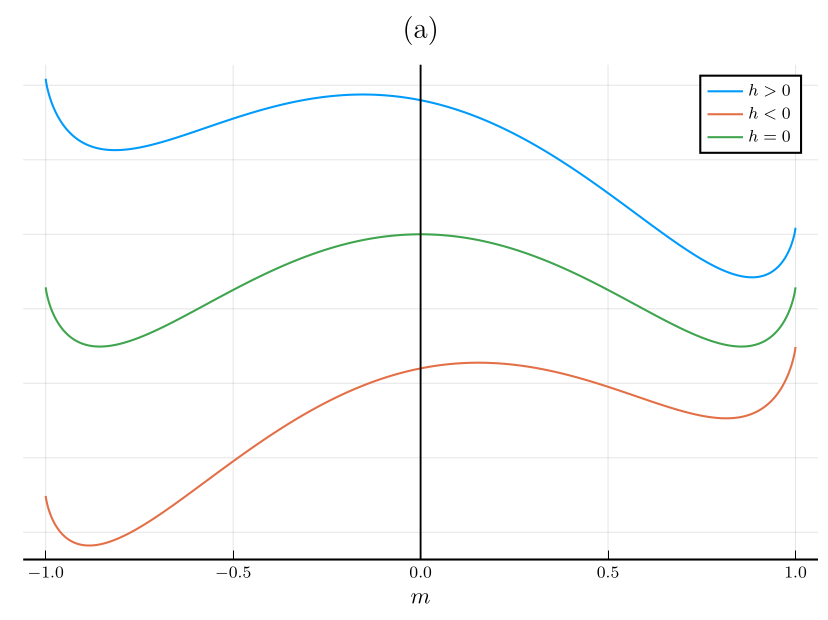

In [40]:
plot(m, g.(m,0.1,0.67) .+ 0.18, label=L"h>0")
plot!(m, g.(m,-0.1,0.67).- 0.18, label=L"h<0")
plot!(m, g.(m,0.0,0.67), yaxis=false, label=L"h=0", xlabel=L"m", legend=:topright, title="(a)")
p2 = vline!([0], c="black", lw=0.9, label="")

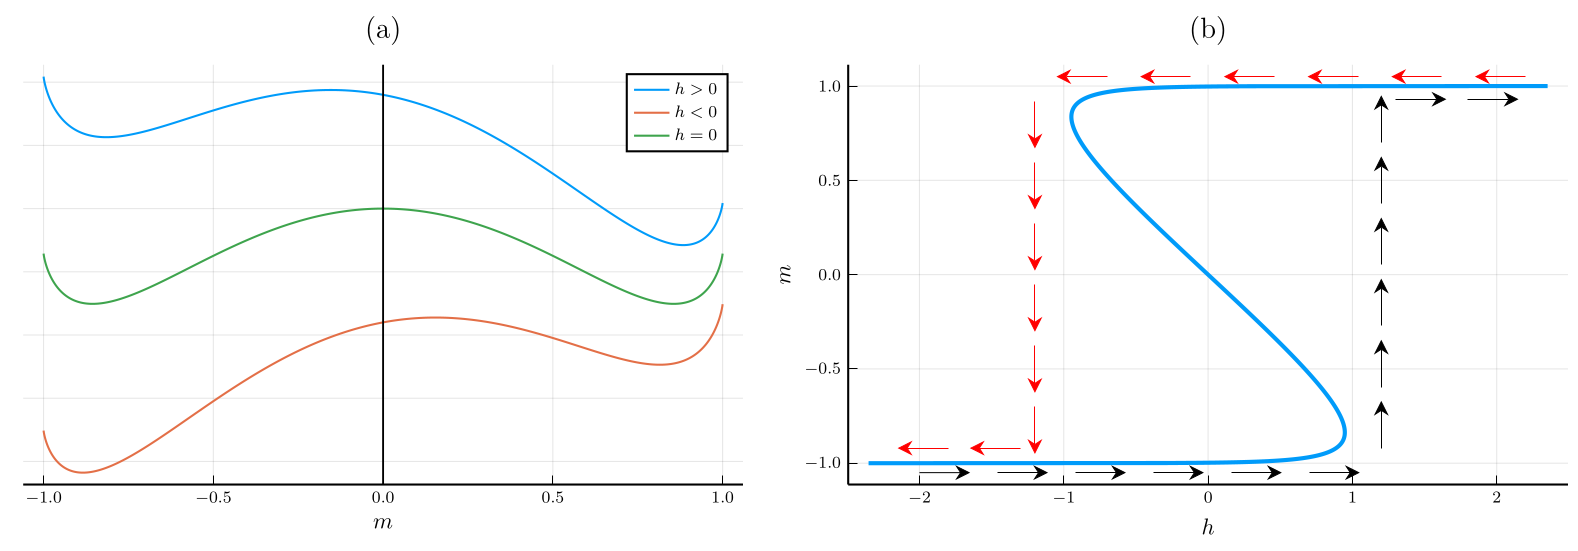

In [41]:
plot(p2,p1, size=(1100, 350))

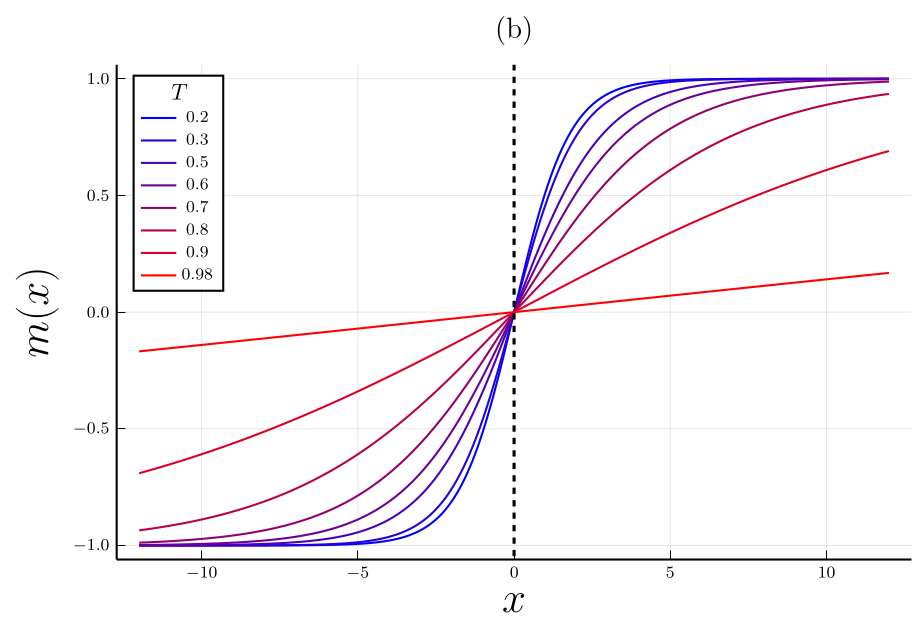

In [82]:
pgfplotsx()
Tarr = [0.2,0.3,0.5,0.6,0.7,0.8,0.9,0.98]
c1 = RGB(0, 0, 1)
c2 = RGB(1, 0, 0)
plot(legend=:topleft,
     legend_title=L"T",
     legend_column=1)
cmap = [RGB( (1 - t) * red(c1) + t * red(c2), (1 - t) * green(c1) + t * green(c2), (1 - t) * blue(c1) + t * blue(c2) ) for t in range(0, 1, length=length(Tarr))]

m(x,xo,T) = tanh((x-xo)/(sqrt(2)*(1/(1-T))))
x = LinRange(-12,12,300)
k=1
for T in Tarr
plot!(x, m.(x,0,T), c=cmap[k], label="$T")
k+=1
end
vline!([0], ls=:dash, lw=1.5, c="black", label="")
p1 = plot!(xlabel=L"x", ylabel=L"m(x)", guidefontsize=20, labelfontsize=20, title="(b)")

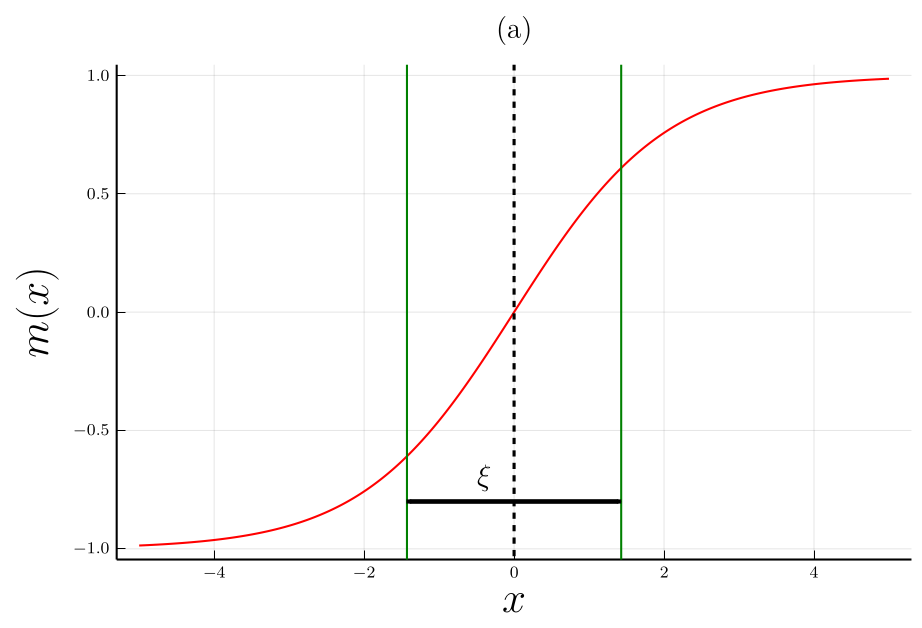

In [91]:
pgfplotsx()
Tarr = [0.3]
c1 = RGB(0, 0, 1)
c2 = RGB(1, 0, 0)
plot(legend=:topleft,
     legend_column=1)
m(x,xo,T) = tanh((x-xo)/(sqrt(2)*(1/(1-T))))
x = LinRange(-5,5,300)
k=1
for T in Tarr
plot!(x, m.(x,0,T), c="red", label="")
vline!([-1/(1-T), 1/(1-T)], label="", c="green")
k+=1
end
vline!([0], ls=:dash, lw=1.5, c="black", label="")
plot!(xlabel=L"x", ylabel=L"m(x)", guidefontsize=20, labelfontsize=20, title="(a)")
T=0.3
width = 1/(1-T)
p2=plot!([-width, width], [-0.8, -0.8],
      arrow = (:both, 2.0),
      lw = 2,
      c = :black,
      label = "")
      annotate!([(-0.4,-0.7, L"\xi")], label="")
      
     

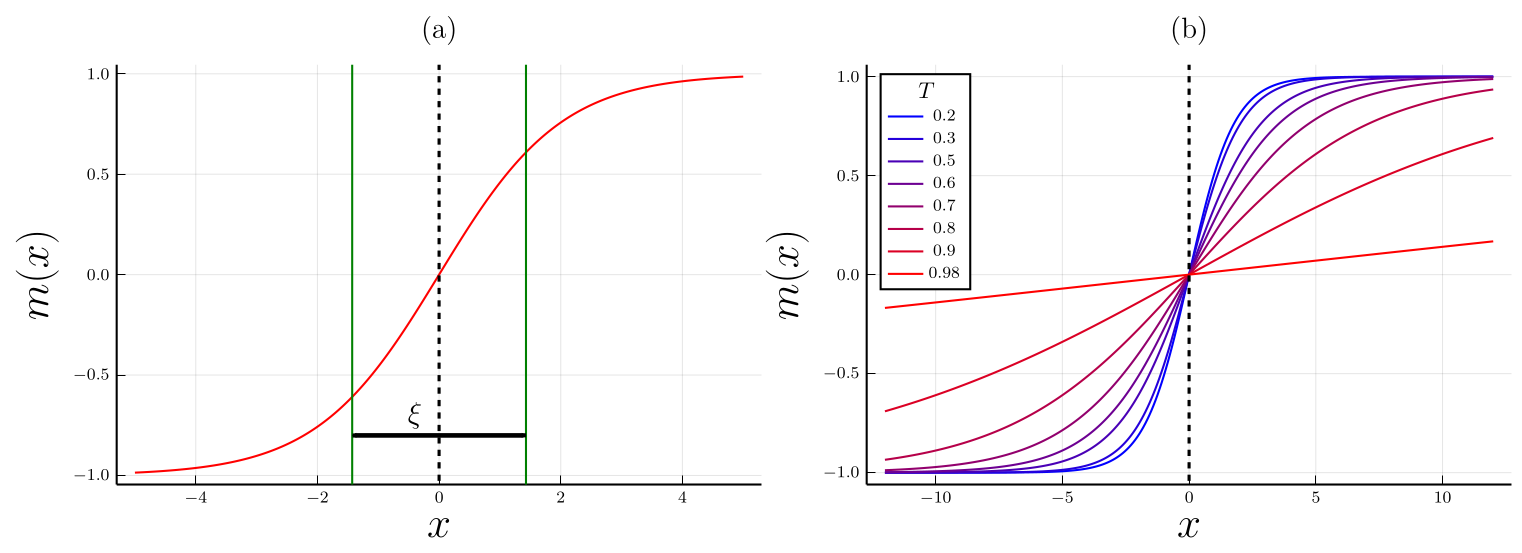

In [92]:
plot(p2,p1, size=(1000,350))

In [93]:
savefig("correlation.pdf")

"/home/shaggy1304/IISER/IISER_Courses/Notes/AdvStatMech/codes/correlation.pdf"

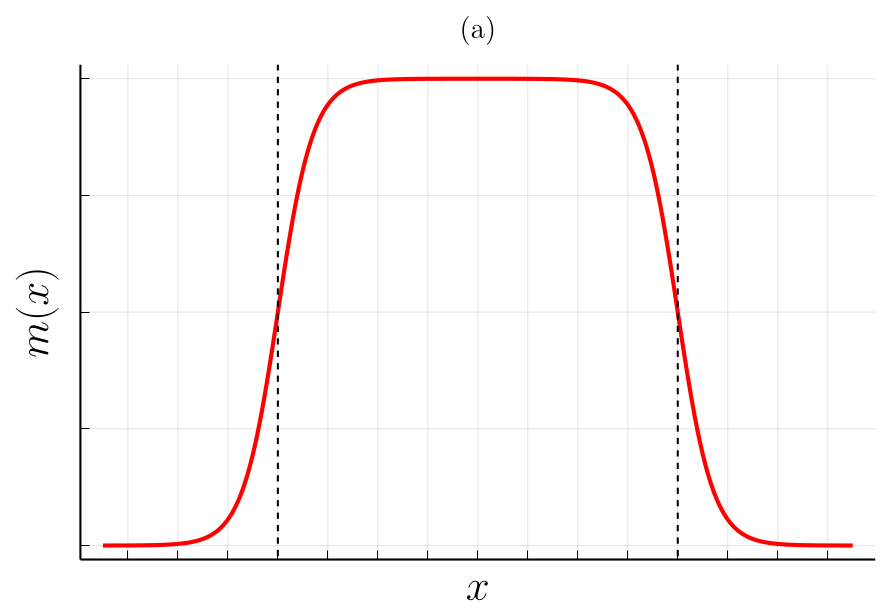

In [116]:
using Plots
pgfplotsx()

m0 = 1.0
ξ  = 1.0
a  = 8.0      # half-separation between kink and antikink

x = LinRange(-15,15,1000)

# single kink
kink(x) = m0 * tanh(x/(sqrt(2)*ξ))

# kink–antikink pair
pair(x) = m0*(tanh((x+a)/(sqrt(2)*ξ)) -
              tanh((x-a)/(sqrt(2)*ξ)) - 1)

plot(x, pair.(x),
     lw=2,
     c=:red,
     xlabel=L"x",
     ylabel=L"m(x)",
     legend=false,
     xticks=[], yticks=[])

p1 = vline!([-a, a], ls=:dash, c=:black, labelfontsize=20, title="(a)")

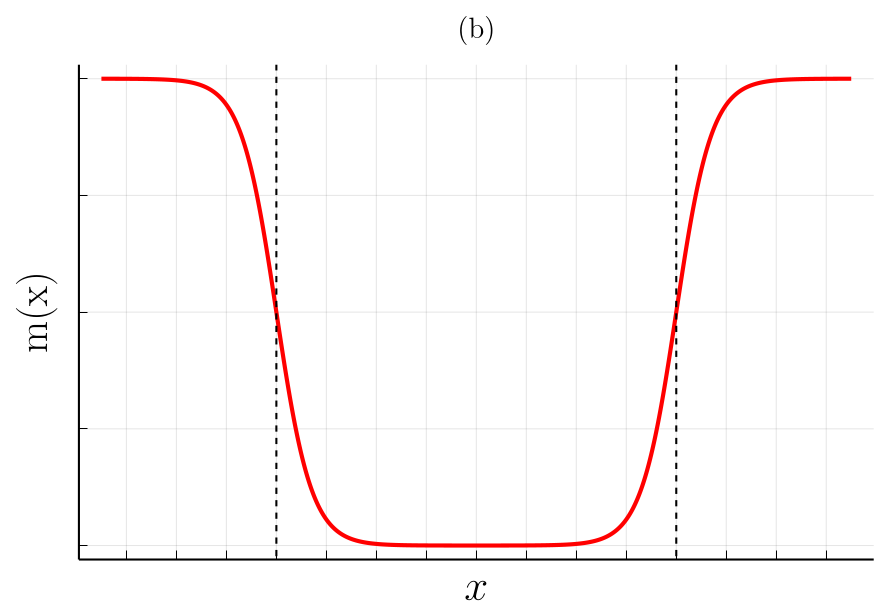

In [123]:
m0 = 1.0
ξ  = 1.0
a  = 8.0      # half-separation between kink and antikink

x = LinRange(-15,15,1000)

# single kink
kink(x) = m0 * tanh(x/(sqrt(2)*ξ))

# kink–antikink pair
pair(x) = m0*(-tanh((x+a)/(sqrt(2)*ξ)) +
              tanh((x-a)/(sqrt(2)*ξ)) - 1)

plot(x, pair.(x),
     lw=2,
     c=:red,
     xlabel=L"x",
     ylabel="m(x)",
     legend=false,
     xticks=[], yticks=[])

p2 = vline!([-a, a], ls=:dash, c=:black, labelfontsize=20, title="(b)")

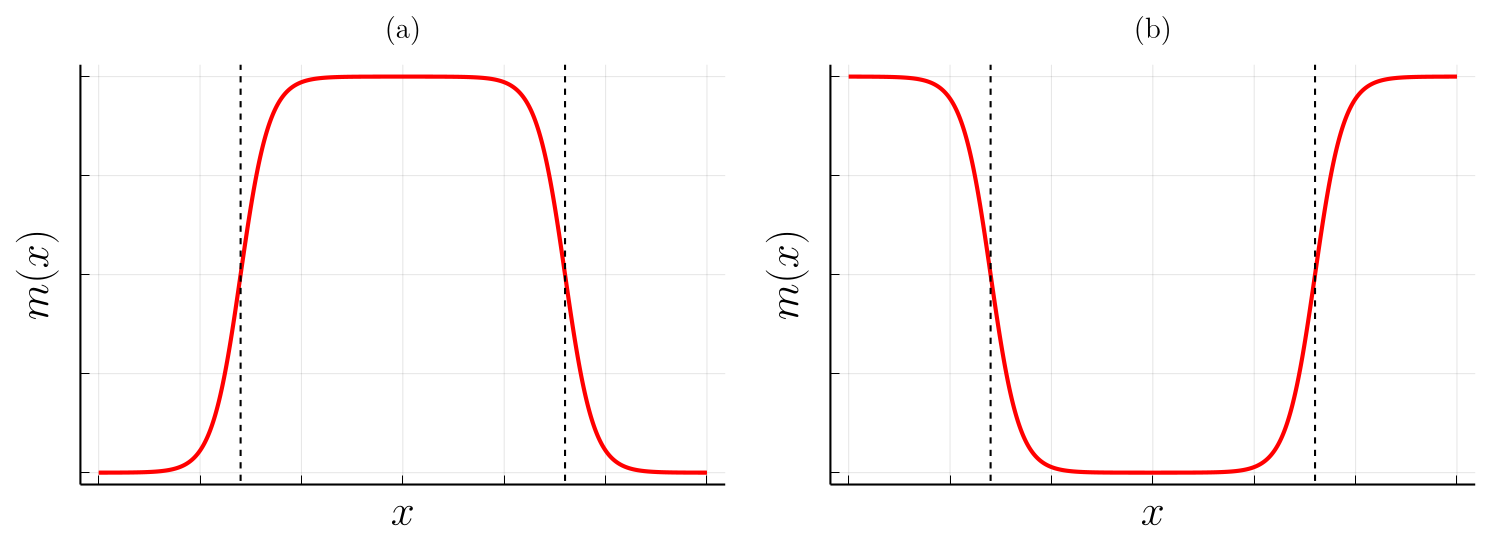

In [118]:
plot(p1,p2, size=(1000,350))

In [119]:
savefig("twokink.pdf")

"/home/shaggy1304/IISER/IISER_Courses/Notes/AdvStatMech/codes/twokink.pdf"